# 07 — Final 2026 evaluation, full 336-hour target

This is the updated final-evaluation notebook.

It evaluates the already-frozen:

- **Raw GFS** baseline
- **Linear Regression**
- **XGBoost**

on the exact assignment period:

**September 17, 2026 12:00 AM EDT through September 30, 2026 11:00 PM EDT**

That is exactly **336 hourly temperatures**.

## Why this version is different

The first final-evaluation notebook found only 322/336 temperatures in the current NOAA/NCEI GHCNh station-year file.

This notebook first refreshes GHCNh. If GHCNh still has gaps in the target period, it fills **only those missing actual observations** from the NOAA/NWS Aviation Weather Center (AWC) `KRDU` METAR archive.

The workflow is deliberately conservative:

1. Refresh the official NOAA GHCNh RDU station file.
2. Build the hourly GHCNh targets using exactly the same selection rule used during training.
3. If any target hours are missing, fetch KRDU METARs from the official Aviation Weather Center API.
4. Validate AWC temperatures against overlapping GHCNh hours.
5. Fill only missing GHCNh target hours with AWC METAR temperatures.
6. Require **336/336 actual hours** before final scoring.
7. Recompute every metric and plot on the complete target.

No model is trained, refit, or tuned here.

## Ground-truth provenance

The final hourly actual-temperature table records `actual_source` for every row:

- `NOAA_GHCNh`
- `NOAA_AWC_METAR`

So the patch is fully auditable.

## Outputs

- `data/raw/RDU_ACTUAL_2026_TARGET_FULL336.csv`
- `data/processed/final_2026_evaluation_hourly_FULL336.csv`
- `data/processed/final_2026_metrics_overall_FULL336.csv`
- `data/processed/final_2026_metrics_by_day_FULL336.csv`
- `data/processed/final_2026_metrics_by_horizon_FULL336.csv`
- plots under `reports/figures/final_2026_full336/`

In [1]:
from pathlib import Path
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

from IPython.display import display

## 1. Locate the project and frozen forecast files

In [2]:
def find_project_root():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd().parent.parent,
    ]

    for candidate in candidates:
        processed = candidate / "data" / "processed"

        if (
            (processed / "linear_regression_2026_predictions.csv").exists()
            and (processed / "xgboost_2026_predictions.csv").exists()
        ):
            return candidate.resolve()

    raise FileNotFoundError(
        "Could not find the frozen 2026 prediction files. "
        "Run notebooks 05 and 06 first."
    )


PROJECT_ROOT = find_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "final_2026_full336"
)

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

LINEAR_PATH = (
    PROCESSED_DIR
    / "linear_regression_2026_predictions.csv"
)

XGB_PATH = (
    PROCESSED_DIR
    / "xgboost_2026_predictions.csv"
)

print("Project root:", PROJECT_ROOT)
print("Linear predictions:", LINEAR_PATH)
print("XGBoost predictions:", XGB_PATH)
print("Figure output:", FIGURE_DIR)

Project root: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU
Linear predictions: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/linear_regression_2026_predictions.csv
XGBoost predictions: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/xgboost_2026_predictions.csv
Figure output: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336


## 2. Define the exact target period

In [3]:
LOCAL_TZ = "America/New_York"

TARGET_START_LOCAL = pd.Timestamp(
    "2026-09-17 00:00:00",
    tz=LOCAL_TZ,
)

TARGET_END_LOCAL = pd.Timestamp(
    "2026-09-30 23:00:00",
    tz=LOCAL_TZ,
)

TARGET_START_UTC = TARGET_START_LOCAL.tz_convert("UTC")
TARGET_END_UTC = TARGET_END_LOCAL.tz_convert("UTC")

EXPECTED_HOURS_UTC = pd.date_range(
    TARGET_START_UTC,
    TARGET_END_UTC,
    freq="h",
)

print("Target start local:", TARGET_START_LOCAL)
print("Target end local:  ", TARGET_END_LOCAL)
print("Target start UTC:  ", TARGET_START_UTC)
print("Target end UTC:    ", TARGET_END_UTC)
print("Expected hours:    ", len(EXPECTED_HOURS_UTC))

assert len(EXPECTED_HOURS_UTC) == 336

Target start local: 2026-09-17 00:00:00-04:00
Target end local:   2026-09-30 23:00:00-04:00
Target start UTC:   2026-09-17 04:00:00+00:00
Target end UTC:     2026-10-01 03:00:00+00:00
Expected hours:     336


## 3. Load and audit the frozen model predictions

In [4]:
linear = pd.read_csv(
    LINEAR_PATH,
    parse_dates=[
        "valid_time_utc",
        "valid_time_local",
    ],
)

xgb = pd.read_csv(
    XGB_PATH,
    parse_dates=[
        "valid_time_utc",
        "valid_time_local",
    ],
)

for frame in [linear, xgb]:
    frame["valid_time_utc"] = pd.to_datetime(
        frame["valid_time_utc"],
        utc=True,
    )

required_linear = {
    "valid_time_utc",
    "forecast_hour",
    "raw_gfs_temp_f",
    "linear_regression_temp_f",
}

required_xgb = {
    "valid_time_utc",
    "forecast_hour",
    "raw_gfs_temp_f",
    "xgboost_temp_f",
}

missing_linear = required_linear - set(linear.columns)
missing_xgb = required_xgb - set(xgb.columns)

if missing_linear:
    raise KeyError(
        f"Linear file missing: {sorted(missing_linear)}"
    )

if missing_xgb:
    raise KeyError(
        f"XGBoost file missing: {sorted(missing_xgb)}"
    )

assert len(linear) == 336
assert len(xgb) == 336

assert linear["valid_time_utc"].duplicated().sum() == 0
assert xgb["valid_time_utc"].duplicated().sum() == 0

assert set(linear["valid_time_utc"]) == set(EXPECTED_HOURS_UTC)
assert set(xgb["valid_time_utc"]) == set(EXPECTED_HOURS_UTC)

gfs_crosscheck = (
    linear[
        [
            "valid_time_utc",
            "raw_gfs_temp_f",
        ]
    ]
    .merge(
        xgb[
            [
                "valid_time_utc",
                "raw_gfs_temp_f",
            ]
        ],
        on="valid_time_utc",
        validate="one_to_one",
        suffixes=(
            "_linear_file",
            "_xgb_file",
        ),
    )
)

max_gfs_diff = (
    gfs_crosscheck[
        "raw_gfs_temp_f_linear_file"
    ]
    - gfs_crosscheck[
        "raw_gfs_temp_f_xgb_file"
    ]
).abs().max()

print(
    "Maximum raw-GFS difference between prediction files:",
    max_gfs_diff,
    "°F",
)

assert max_gfs_diff < 1e-9

print(
    "PASS: both frozen prediction files contain the same "
    "336 target hours and the same GFS baseline."
)

Maximum raw-GFS difference between prediction files: 0.0 °F
PASS: both frozen prediction files contain the same 336 target hours and the same GFS baseline.


# Part A — Build complete observed ground truth

## 4. Refresh NOAA GHCNh

We first try the same NOAA/NCEI source used for our historical actuals. The 2026 file may now have ingested the previously missing Sept. 30 observations.

In [5]:
GHCNH_STATION_ID = "USW00013722"
GHCNH_YEAR = 2026

GHCNH_URL = (
    "https://www.ncei.noaa.gov/oa/"
    "global-historical-climatology-network/hourly/"
    f"access/by-year/{GHCNH_YEAR}/psv/"
    f"GHCNh_{GHCNH_STATION_ID}_{GHCNH_YEAR}.psv"
)

CACHE_DIR = RAW_DIR / "ghcnh_cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

GHCNH_CACHE_PATH = (
    CACHE_DIR
    / f"GHCNh_{GHCNH_STATION_ID}_{GHCNH_YEAR}.psv"
)

print("GHCNh URL:")
print(GHCNH_URL)
print("\nCache path:")
print(GHCNH_CACHE_PATH)

GHCNh URL:
https://www.ncei.noaa.gov/oa/global-historical-climatology-network/hourly/access/by-year/2026/psv/GHCNh_USW00013722_2026.psv

Cache path:
/home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/raw/ghcnh_cache/GHCNh_USW00013722_2026.psv


In [6]:
def make_retry_session():
    session = requests.Session()

    retry = Retry(
        total=5,
        connect=5,
        read=5,
        backoff_factor=1.5,
        status_forcelist=(
            429,
            500,
            502,
            503,
            504,
        ),
        allowed_methods=("GET",),
    )

    session.mount(
        "https://",
        HTTPAdapter(max_retries=retry),
    )

    session.headers.update({
        "User-Agent": (
            "Duke-AIPI520-RDU-weather-project/"
            "final-evaluation"
        )
    })

    return session


def normalize_column_name(name):
    name = str(name).strip().lower()
    name = re.sub(
        r"[^a-z0-9]+",
        "_",
        name,
    )
    return name.strip("_")


def parse_ghcnh_file(path):
    df = pd.read_csv(
        path,
        sep="|",
        low_memory=False,
    )

    df.columns = [
        normalize_column_name(c)
        for c in df.columns
    ]

    required = [
        "year",
        "month",
        "day",
        "hour",
        "minute",
        "temperature",
    ]

    missing = [
        c
        for c in required
        if c not in df.columns
    ]

    if missing:
        raise KeyError(
            "GHCNh file is missing expected columns: "
            f"{missing}"
        )

    for c in [
        "year",
        "month",
        "day",
        "hour",
        "minute",
    ]:
        df[c] = pd.to_numeric(
            df[c],
            errors="coerce",
        )

    df["observation_time_utc"] = pd.to_datetime(
        {
            "year": df["year"],
            "month": df["month"],
            "day": df["day"],
            "hour": df["hour"],
            "minute": df["minute"],
        },
        errors="coerce",
        utc=True,
    )

    df["temperature"] = pd.to_numeric(
        df["temperature"],
        errors="coerce",
    )

    return df.dropna(
        subset=["observation_time_utc"]
    )


ghcnh_session = make_retry_session()

try:
    print("Downloading a fresh 2026 GHCNh file...")

    response = ghcnh_session.get(
        GHCNH_URL,
        timeout=120,
    )
    response.raise_for_status()

    head = response.content[:500].lower()

    if (
        b"<html" in head
        or b"<!doctype" in head
    ):
        raise RuntimeError(
            "NOAA returned HTML instead of a PSV data file."
        )

    GHCNH_CACHE_PATH.write_bytes(
        response.content
    )

    print(
        "Fresh GHCNh file saved:",
        GHCNH_CACHE_PATH,
    )

except Exception as exc:
    print(
        "Fresh GHCNh download failed:",
        repr(exc),
    )

    if GHCNH_CACHE_PATH.exists():
        print(
            "Using the existing cached 2026 GHCNh file. "
            "Any remaining gaps will be handled by AWC METAR."
        )
    else:
        raise RuntimeError(
            "No GHCNh file is available. "
            "Download the printed URL manually and save it at the cache path."
        ) from exc

Fresh GHCNh file saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/raw/ghcnh_cache/GHCNh_USW00013722_2026.psv


## 5. Select the hourly GHCNh observations using the training-time rule

In [7]:
def select_one_hourly_temperature(
    observations,
    time_column,
    temperature_c_column,
):
    df = observations.copy()

    df[time_column] = pd.to_datetime(
        df[time_column],
        utc=True,
    )

    df["hour_utc"] = (
        df[time_column]
        .dt.floor("h")
    )

    df["minute"] = (
        df[time_column]
        .dt.minute
    )

    df["_temp_missing"] = (
        df[temperature_c_column]
        .isna()
        .astype(int)
    )

    df["_late_hour"] = (
        df["minute"]
        .between(45, 59)
        .astype(int)
    )

    df["_distance_from_51"] = (
        df["minute"] - 51
    ).abs()

    df = df.sort_values(
        by=[
            "hour_utc",
            "_temp_missing",
            "_late_hour",
            "_distance_from_51",
            time_column,
        ],
        ascending=[
            True,
            True,
            False,
            True,
            True,
        ],
    )

    selected = (
        df
        .drop_duplicates(
            subset=["hour_utc"],
            keep="first",
        )
        .sort_values("hour_utc")
        .reset_index(drop=True)
    )

    selected["actual_temp_c"] = pd.to_numeric(
        selected[temperature_c_column],
        errors="coerce",
    )

    selected["actual_temp_f"] = (
        selected["actual_temp_c"]
        * 9.0 / 5.0
        + 32.0
    )

    return selected


ghcnh = parse_ghcnh_file(
    GHCNH_CACHE_PATH
)

ghcnh_target_obs = ghcnh[
    (
        ghcnh["observation_time_utc"]
        >= TARGET_START_UTC
    )
    & (
        ghcnh["observation_time_utc"]
        < TARGET_END_UTC
        + pd.Timedelta(hours=1)
    )
].copy()

ghcnh_hourly = select_one_hourly_temperature(
    ghcnh_target_obs,
    time_column="observation_time_utc",
    temperature_c_column="temperature",
)

ghcnh_hourly = ghcnh_hourly[
    [
        "hour_utc",
        "observation_time_utc",
        "minute",
        "actual_temp_c",
        "actual_temp_f",
    ]
].copy()

ghcnh_hourly[
    "actual_source"
] = "NOAA_GHCNh"

expected_hours = pd.DataFrame({
    "hour_utc": EXPECTED_HOURS_UTC
})

ghcnh_target = (
    expected_hours
    .merge(
        ghcnh_hourly,
        on="hour_utc",
        how="left",
        validate="one_to_one",
    )
)

ghcnh_present = (
    ghcnh_target[
        "actual_temp_f"
    ].notna().sum()
)

print(
    "GHCNh actual-temperature coverage:",
    f"{ghcnh_present}/336 "
    f"({ghcnh_present / 336:.2%})",
)

ghcnh_missing_hours = (
    ghcnh_target.loc[
        ghcnh_target[
            "actual_temp_f"
        ].isna(),
        "hour_utc",
    ]
    .tolist()
)

if ghcnh_missing_hours:
    print("\nStill missing from GHCNh:")
    for x in ghcnh_missing_hours:
        print(" ", x)
else:
    print(
        "\nExcellent: refreshed GHCNh now contains all 336 hours. "
        "AWC gap-fill will not be needed."
    )

GHCNh actual-temperature coverage: 322/336 (95.83%)

Still missing from GHCNh:
  2026-09-30 14:00:00+00:00
  2026-09-30 15:00:00+00:00
  2026-09-30 16:00:00+00:00
  2026-09-30 17:00:00+00:00
  2026-09-30 18:00:00+00:00
  2026-09-30 19:00:00+00:00
  2026-09-30 20:00:00+00:00
  2026-09-30 21:00:00+00:00
  2026-09-30 22:00:00+00:00
  2026-09-30 23:00:00+00:00
  2026-10-01 00:00:00+00:00
  2026-10-01 01:00:00+00:00
  2026-10-01 02:00:00+00:00
  2026-10-01 03:00:00+00:00


## 6. Fetch KRDU METARs from NOAA/NWS Aviation Weather Center if needed

The AWC API exposes decoded METAR observations. We query a 72-hour window ending immediately after the assignment period. This gives us:

- the missing late-Sept.-30 observations
- substantial overlap with GHCNh for validation

We try both accepted date syntaxes because AviationWeather has historically documented both ISO timestamps and compact `yyyymmdd_hhmm` timestamps.

In [8]:
AWC_ENDPOINT = (
    "https://aviationweather.gov/"
    "api/data/metar"
)

AWC_STATION_ID = "KRDU"

AWC_QUERY_END = (
    TARGET_END_UTC
    + pd.Timedelta(hours=1)
)

AWC_HOURS = 72

AWC_CACHE_PATH = (
    RAW_DIR
    / "KRDU_AWC_METAR_SEP30_2026.csv"
)

print("AWC endpoint:", AWC_ENDPOINT)
print("AWC station:", AWC_STATION_ID)
print("Query end:", AWC_QUERY_END)
print("Lookback hours:", AWC_HOURS)

AWC endpoint: https://aviationweather.gov/api/data/metar
AWC station: KRDU
Query end: 2026-10-01 04:00:00+00:00
Lookback hours: 72


In [9]:
def parse_awc_obs_time(record):
    candidates = [
        record.get("obsTime"),
        record.get("reportTime"),
        record.get("receiptTime"),
    ]

    for value in candidates:
        if value is None:
            continue

        # obsTime may be Unix epoch seconds.
        if isinstance(
            value,
            (
                int,
                float,
                np.integer,
                np.floating,
            ),
        ):
            return pd.to_datetime(
                value,
                unit="s",
                utc=True,
            )

        value_text = str(value).strip()

        if (
            value_text.isdigit()
            and len(value_text) >= 9
        ):
            try:
                return pd.to_datetime(
                    int(value_text),
                    unit="s",
                    utc=True,
                )
            except Exception:
                pass

        parsed = pd.to_datetime(
            value_text,
            utc=True,
            errors="coerce",
        )

        if not pd.isna(parsed):
            return parsed

    return pd.NaT


def fetch_awc_metars():
    session = make_retry_session()

    date_iso = AWC_QUERY_END.strftime(
        "%Y-%m-%dT%H:%M:%SZ"
    )

    date_compact = AWC_QUERY_END.strftime(
        "%Y%m%d_%H%M"
    )

    attempts = [
        {
            "ids": AWC_STATION_ID,
            "format": "json",
            "hours": AWC_HOURS,
            "date": date_iso,
        },
        {
            "ids": AWC_STATION_ID,
            "format": "json",
            "hours": AWC_HOURS,
            "date": date_compact,
        },
        # Last-resort narrower historical request.
        {
            "ids": AWC_STATION_ID,
            "format": "json",
            "hours": 48,
            "date": date_compact,
        },
    ]

    errors = []

    for i, params in enumerate(
        attempts,
        start=1,
    ):
        print(
            f"AWC attempt {i}/{len(attempts)}:",
            params,
        )

        try:
            response = session.get(
                AWC_ENDPOINT,
                params=params,
                timeout=90,
            )

            if response.status_code == 204:
                errors.append(
                    f"Attempt {i}: HTTP 204, no data"
                )
                continue

            response.raise_for_status()

            records = response.json()

            if not isinstance(
                records,
                list,
            ):
                errors.append(
                    f"Attempt {i}: JSON was not a list"
                )
                continue

            if len(records) == 0:
                errors.append(
                    f"Attempt {i}: empty list"
                )
                continue

            print(
                f"AWC returned {len(records)} METAR records."
            )

            return records

        except Exception as exc:
            errors.append(
                f"Attempt {i}: {repr(exc)}"
            )

            time.sleep(1)

    raise RuntimeError(
        "All AWC METAR query attempts failed.\n"
        + "\n".join(errors)
        + "\n\nDo not fabricate the remaining actual temperatures. "
        "Open the AviationWeather Data API documentation and manually "
        "download KRDU METARs covering Sept. 29–Oct. 1, 2026, then "
        "save them or send the error output back."
    )

In [10]:
if len(ghcnh_missing_hours) == 0:
    awc_hourly = pd.DataFrame()

    print(
        "GHCNh is already complete. "
        "Skipping AWC download."
    )

else:
    try:
        awc_records = fetch_awc_metars()

        awc_rows = []

        for record in awc_records:
            obs_time = parse_awc_obs_time(
                record
            )

            temp_c = pd.to_numeric(
                record.get("temp"),
                errors="coerce",
            )

            awc_rows.append({
                "icao_id": record.get(
                    "icaoId"
                ),
                "observation_time_utc": obs_time,
                "temperature_c": temp_c,
                "metar_type": record.get(
                    "metarType"
                ),
                "raw_ob": record.get(
                    "rawOb"
                ),
            })

        awc_raw = pd.DataFrame(
            awc_rows
        )

        awc_raw = awc_raw[
            awc_raw[
                "icao_id"
            ].astype(str).str.upper()
            == AWC_STATION_ID
        ].copy()

        awc_raw = awc_raw.dropna(
            subset=[
                "observation_time_utc"
            ]
        )

        awc_raw = awc_raw[
            (
                awc_raw[
                    "observation_time_utc"
                ]
                >= TARGET_START_UTC
                - pd.Timedelta(hours=48)
            )
            & (
                awc_raw[
                    "observation_time_utc"
                ]
                < TARGET_END_UTC
                + pd.Timedelta(hours=1)
            )
        ].copy()

        print(
            "Parsed KRDU METAR records:",
            len(awc_raw),
        )

        awc_hourly = select_one_hourly_temperature(
            awc_raw,
            time_column="observation_time_utc",
            temperature_c_column="temperature_c",
        )

        awc_hourly = awc_hourly[
            [
                "hour_utc",
                "observation_time_utc",
                "minute",
                "actual_temp_c",
                "actual_temp_f",
                "metar_type",
                "raw_ob",
            ]
        ].copy()

        awc_hourly[
            "actual_source"
        ] = "NOAA_AWC_METAR"

        awc_hourly.to_csv(
            AWC_CACHE_PATH,
            index=False,
        )

        print(
            "Saved decoded AWC observations:",
            AWC_CACHE_PATH,
        )

        display(
            awc_hourly.tail(24)
        )

    except Exception:
        print(
            "\nAWC automatic retrieval did not succeed."
        )
        raise

AWC attempt 1/3: {'ids': 'KRDU', 'format': 'json', 'hours': 72, 'date': '2026-10-01T04:00:00Z'}
AWC returned 72 METAR records.
Parsed KRDU METAR records: 72
Saved decoded AWC observations: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/raw/KRDU_AWC_METAR_SEP30_2026.csv


,hour_utc,observation_time_utc,minute,actual_temp_c,actual_temp_f,metar_type,raw_ob,actual_source
48,2026-09-30 04:00:00+00:00,2026-09-30 04:51:00+00:00,51,18.9,66.02,METAR,METAR KRDU 300451Z 00000KT 10SM FEW055 19/17 A...,NOAA_AWC_METAR
49,2026-09-30 05:00:00+00:00,2026-09-30 05:51:00+00:00,51,18.3,64.94,METAR,METAR KRDU 300551Z 00000KT 10SM CLR 18/17 A300...,NOAA_AWC_METAR
50,2026-09-30 06:00:00+00:00,2026-09-30 06:51:00+00:00,51,17.2,62.96,METAR,METAR KRDU 300651Z 00000KT 10SM CLR 17/16 A300...,NOAA_AWC_METAR
51,2026-09-30 07:00:00+00:00,2026-09-30 07:51:00+00:00,51,16.7,62.06,METAR,METAR KRDU 300751Z 00000KT 10SM CLR 17/16 A300...,NOAA_AWC_METAR
52,2026-09-30 08:00:00+00:00,2026-09-30 08:51:00+00:00,51,16.1,60.98,METAR,METAR KRDU 300851Z 00000KT 10SM FEW060 16/16 A...,NOAA_AWC_METAR
53,2026-09-30 09:00:00+00:00,2026-09-30 09:51:00+00:00,51,16.1,60.98,METAR,METAR KRDU 300951Z 00000KT 8SM CLR 16/16 A3010...,NOAA_AWC_METAR
54,2026-09-30 10:00:00+00:00,2026-09-30 10:51:00+00:00,51,16.1,60.98,METAR,METAR KRDU 301051Z 00000KT 4SM BR FEW060 16/16...,NOAA_AWC_METAR
55,2026-09-30 11:00:00+00:00,2026-09-30 11:51:00+00:00,51,16.7,62.06,METAR,METAR KRDU 301151Z 36003KT 8SM FEW002 FEW060 1...,NOAA_AWC_METAR
56,2026-09-30 12:00:00+00:00,2026-09-30 12:51:00+00:00,51,18.3,64.94,METAR,METAR KRDU 301251Z 36003KT 10SM FEW003 18/17 A...,NOAA_AWC_METAR
57,2026-09-30 13:00:00+00:00,2026-09-30 13:51:00+00:00,51,22.2,71.96,METAR,METAR KRDU 301351Z 00000KT 10SM FEW250 22/18 A...,NOAA_AWC_METAR


## 7. Validate AWC against overlapping GHCNh observations

Before using AWC to fill a missing target hour, compare the two official sources over hours where both have a temperature.

We expect small differences from report selection / METAR rounding, but not a systematically different temperature series.

In [11]:
if len(ghcnh_missing_hours) == 0:
    overlap_validation = pd.DataFrame()

    print(
        "No gap-fill needed; overlap validation is unnecessary."
    )

else:
    overlap_validation = (
        ghcnh_hourly[
            [
                "hour_utc",
                "actual_temp_f",
            ]
        ]
        .dropna()
        .merge(
            awc_hourly[
                [
                    "hour_utc",
                    "actual_temp_f",
                ]
            ].dropna(),
            on="hour_utc",
            how="inner",
            suffixes=(
                "_ghcnh",
                "_awc",
            ),
        )
    )

    if len(overlap_validation) < 12:
        raise RuntimeError(
            "Too few overlapping GHCNh/AWC hours to validate the gap-fill "
            f"({len(overlap_validation)} overlaps)."
        )

    overlap_validation[
        "abs_diff_f"
    ] = (
        overlap_validation[
            "actual_temp_f_ghcnh"
        ]
        - overlap_validation[
            "actual_temp_f_awc"
        ]
    ).abs()

    overlap_mae = (
        overlap_validation[
            "abs_diff_f"
        ].mean()
    )

    overlap_p95 = (
        overlap_validation[
            "abs_diff_f"
        ].quantile(0.95)
    )

    overlap_max = (
        overlap_validation[
            "abs_diff_f"
        ].max()
    )

    print(
        "Overlap hours:",
        len(overlap_validation),
    )
    print(
        "Mean absolute difference:",
        f"{overlap_mae:.3f} °F",
    )
    print(
        "95th-percentile absolute difference:",
        f"{overlap_p95:.3f} °F",
    )
    print(
        "Maximum absolute difference:",
        f"{overlap_max:.3f} °F",
    )

    display(
        overlap_validation.sort_values(
            "abs_diff_f",
            ascending=False,
        ).head(15)
    )

    # Conservative source-consistency guard.
    if (
        overlap_mae > 1.0
        or overlap_p95 > 2.0
    ):
        raise RuntimeError(
            "STOP: AWC and GHCNh do not agree closely enough over their "
            "overlap to use AWC automatically as a gap-fill. "
            "Inspect the overlap table before proceeding."
        )

    print(
        "\nPASS: AWC METAR temperatures agree closely with GHCNh."
    )

Overlap hours: 58
Mean absolute difference: 0.000 °F
95th-percentile absolute difference: 0.000 °F
Maximum absolute difference: 0.000 °F


,hour_utc,actual_temp_f_ghcnh,actual_temp_f_awc,abs_diff_f
0,2026-09-28 04:00:00+00:00,64.04,64.04,0.0
1,2026-09-28 05:00:00+00:00,60.98,60.98,0.0
2,2026-09-28 06:00:00+00:00,57.92,57.92,0.0
3,2026-09-28 07:00:00+00:00,57.92,57.92,0.0
4,2026-09-28 08:00:00+00:00,57.02,57.02,0.0
5,2026-09-28 09:00:00+00:00,55.94,55.94,0.0
6,2026-09-28 10:00:00+00:00,55.94,55.94,0.0
7,2026-09-28 11:00:00+00:00,57.92,57.92,0.0
8,2026-09-28 12:00:00+00:00,62.96,62.96,0.0
9,2026-09-28 13:00:00+00:00,69.08,69.08,0.0



PASS: AWC METAR temperatures agree closely with GHCNh.


## 8. Fill only the missing GHCNh hours and require 336/336 coverage

In [12]:
full_actual = ghcnh_target.copy()

if len(ghcnh_missing_hours) > 0:
    awc_patch = (
        expected_hours
        .merge(
            awc_hourly[
                [
                    "hour_utc",
                    "observation_time_utc",
                    "minute",
                    "actual_temp_c",
                    "actual_temp_f",
                    "actual_source",
                ]
            ],
            on="hour_utc",
            how="left",
            validate="one_to_one",
        )
    )

    missing_mask = (
        full_actual[
            "actual_temp_f"
        ].isna()
    )

    patch_lookup = (
        awc_patch
        .set_index("hour_utc")
    )

    for idx in full_actual.index[
        missing_mask
    ]:
        hour = full_actual.at[
            idx,
            "hour_utc",
        ]

        if hour not in patch_lookup.index:
            continue

        row = patch_lookup.loc[
            hour
        ]

        if pd.isna(
            row[
                "actual_temp_f"
            ]
        ):
            continue

        for column in [
            "observation_time_utc",
            "minute",
            "actual_temp_c",
            "actual_temp_f",
            "actual_source",
        ]:
            full_actual.at[
                idx,
                column,
            ] = row[
                column
            ]

full_actual[
    "hour_local"
] = (
    full_actual[
        "hour_utc"
    ]
    .dt.tz_convert(
        LOCAL_TZ
    )
)

final_present = (
    full_actual[
        "actual_temp_f"
    ].notna().sum()
)

print(
    "Final observed target coverage:",
    f"{final_present}/336",
)

print("\nSource counts:")
print(
    full_actual[
        "actual_source"
    ]
    .value_counts(
        dropna=False
    )
)

if final_present != 336:
    remaining = (
        full_actual.loc[
            full_actual[
                "actual_temp_f"
            ].isna(),
            "hour_utc",
        ]
        .tolist()
    )

    print("\nStill missing:")
    for x in remaining:
        print(" ", x)

    raise RuntimeError(
        "STOP: the final actual-temperature target is not 336/336. "
        "Do not compute final metrics until every target hour is observed."
    )

assert full_actual[
    "hour_utc"
].duplicated().sum() == 0

assert set(
    full_actual[
        "hour_utc"
    ]
) == set(
    EXPECTED_HOURS_UTC
)

TARGET_ACTUAL_OUTPUT = (
    RAW_DIR
    / "RDU_ACTUAL_2026_TARGET_FULL336.csv"
)

full_actual.to_csv(
    TARGET_ACTUAL_OUTPUT,
    index=False,
)

print(
    "\nPASS: complete 336-hour observed target created."
)
print(
    "Saved:",
    TARGET_ACTUAL_OUTPUT,
)

display(
    full_actual.tail(24)
)

Final observed target coverage: 336/336

Source counts:
actual_source
NOAA_GHCNh        322
NOAA_AWC_METAR     14
Name: count, dtype: int64

PASS: complete 336-hour observed target created.
Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/raw/RDU_ACTUAL_2026_TARGET_FULL336.csv


,hour_utc,observation_time_utc,minute,actual_temp_c,actual_temp_f,actual_source,hour_local
312,2026-09-30 04:00:00+00:00,2026-09-30 04:51:00+00:00,51.0,18.9,66.02,NOAA_GHCNh,2026-09-30 00:00:00-04:00
313,2026-09-30 05:00:00+00:00,2026-09-30 05:51:00+00:00,51.0,18.3,64.94,NOAA_GHCNh,2026-09-30 01:00:00-04:00
314,2026-09-30 06:00:00+00:00,2026-09-30 06:51:00+00:00,51.0,17.2,62.96,NOAA_GHCNh,2026-09-30 02:00:00-04:00
315,2026-09-30 07:00:00+00:00,2026-09-30 07:51:00+00:00,51.0,16.7,62.06,NOAA_GHCNh,2026-09-30 03:00:00-04:00
316,2026-09-30 08:00:00+00:00,2026-09-30 08:51:00+00:00,51.0,16.1,60.98,NOAA_GHCNh,2026-09-30 04:00:00-04:00
317,2026-09-30 09:00:00+00:00,2026-09-30 09:51:00+00:00,51.0,16.1,60.98,NOAA_GHCNh,2026-09-30 05:00:00-04:00
318,2026-09-30 10:00:00+00:00,2026-09-30 10:51:00+00:00,51.0,16.1,60.98,NOAA_GHCNh,2026-09-30 06:00:00-04:00
319,2026-09-30 11:00:00+00:00,2026-09-30 11:51:00+00:00,51.0,16.7,62.06,NOAA_GHCNh,2026-09-30 07:00:00-04:00
320,2026-09-30 12:00:00+00:00,2026-09-30 12:51:00+00:00,51.0,18.3,64.94,NOAA_GHCNh,2026-09-30 08:00:00-04:00
321,2026-09-30 13:00:00+00:00,2026-09-30 13:51:00+00:00,51.0,22.2,71.96,NOAA_GHCNh,2026-09-30 09:00:00-04:00


# Part B — Recompute final evaluation on 336/336 hours

## 9. Merge actual temperatures with all frozen predictions

In [13]:
evaluation = (
    linear[
        [
            "valid_time_utc",
            "forecast_hour",
            "target_day",
            "local_hour",
            "raw_gfs_temp_f",
            "linear_regression_temp_f",
        ]
    ]
    .merge(
        xgb[
            [
                "valid_time_utc",
                "xgboost_temp_f",
            ]
        ],
        on="valid_time_utc",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        full_actual[
            [
                "hour_utc",
                "observation_time_utc",
                "actual_temp_f",
                "actual_source",
            ]
        ],
        left_on="valid_time_utc",
        right_on="hour_utc",
        how="left",
        validate="one_to_one",
    )
)

evaluation[
    "valid_time_local"
] = (
    evaluation[
        "valid_time_utc"
    ]
    .dt.tz_convert(
        LOCAL_TZ
    )
)

evaluation[
    "days_since_sep17_midnight"
] = (
    (
        evaluation[
            "valid_time_local"
        ]
        - TARGET_START_LOCAL
    )
    .dt.total_seconds()
    / 86400.0
)

evaluation[
    "day_since_start"
] = (
    np.floor(
        evaluation[
            "days_since_sep17_midnight"
        ]
    )
    .astype(int)
)

evaluation[
    "calendar_date"
] = (
    evaluation[
        "valid_time_local"
    ]
    .dt.date
)

assert len(evaluation) == 336
assert evaluation[
    "actual_temp_f"
].notna().all()

display(
    evaluation[
        [
            "valid_time_local",
            "actual_temp_f",
            "actual_source",
            "raw_gfs_temp_f",
            "linear_regression_temp_f",
            "xgboost_temp_f",
        ]
    ].tail(24)
)

,valid_time_local,actual_temp_f,actual_source,raw_gfs_temp_f,linear_regression_temp_f,xgboost_temp_f
312,2026-09-30 00:00:00-04:00,66.02,NOAA_GHCNh,70.625,72.436687,66.470502
313,2026-09-30 01:00:00-04:00,64.94,NOAA_GHCNh,69.875,71.920868,65.739169
314,2026-09-30 02:00:00-04:00,62.96,NOAA_GHCNh,69.125,71.405049,66.914441
315,2026-09-30 03:00:00-04:00,62.06,NOAA_GHCNh,69.350,71.559795,68.306213
316,2026-09-30 04:00:00-04:00,60.98,NOAA_GHCNh,69.575,71.714541,67.228772
317,2026-09-30 05:00:00-04:00,60.98,NOAA_GHCNh,69.800,71.869286,67.060634
318,2026-09-30 06:00:00-04:00,60.98,NOAA_GHCNh,70.025,72.024032,66.770814
319,2026-09-30 07:00:00-04:00,62.06,NOAA_GHCNh,70.250,72.178777,69.080547
320,2026-09-30 08:00:00-04:00,64.94,NOAA_GHCNh,70.475,72.333523,69.145458
321,2026-09-30 09:00:00-04:00,71.96,NOAA_GHCNh,72.500,73.726233,71.492541


## 10. Overall metrics

In [14]:
MODEL_COLUMNS = {
    "Raw GFS": "raw_gfs_temp_f",
    "Linear Regression": "linear_regression_temp_f",
    "XGBoost": "xgboost_temp_f",
}


def model_prefix(
    model_name,
):
    return (
        model_name
        .lower()
        .replace(" ", "_")
    )


for model_name, prediction_column in MODEL_COLUMNS.items():
    prefix = model_prefix(
        model_name
    )

    evaluation[
        f"{prefix}_error_f"
    ] = (
        evaluation[
            prediction_column
        ]
        - evaluation[
            "actual_temp_f"
        ]
    )

    evaluation[
        f"{prefix}_abs_error_f"
    ] = (
        evaluation[
            f"{prefix}_error_f"
        ].abs()
    )


def score_model(
    frame,
    prediction_column,
):
    y_true = frame[
        "actual_temp_f"
    ].to_numpy()

    y_pred = frame[
        prediction_column
    ].to_numpy()

    error = (
        y_pred
        - y_true
    )

    abs_error = np.abs(
        error
    )

    return {
        "n_hours": len(frame),
        "RMSE_F": np.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "MAE_F": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "Bias_F": error.mean(),
        "Median_AE_F": np.median(
            abs_error
        ),
        "P90_AE_F": np.quantile(
            abs_error,
            0.90,
        ),
        "Max_AE_F": abs_error.max(),
        "R2": r2_score(
            y_true,
            y_pred,
        ),
    }


overall_metrics = pd.DataFrame([
    {
        "model": name,
        **score_model(
            evaluation,
            column,
        ),
    }
    for name, column
    in MODEL_COLUMNS.items()
])

overall_metrics = (
    overall_metrics
    .sort_values(
        [
            "RMSE_F",
            "MAE_F",
        ]
    )
    .reset_index(
        drop=True
    )
)

raw_rmse = (
    overall_metrics.loc[
        overall_metrics[
            "model"
        ] == "Raw GFS",
        "RMSE_F",
    ]
    .iloc[0]
)

raw_mae = (
    overall_metrics.loc[
        overall_metrics[
            "model"
        ] == "Raw GFS",
        "MAE_F",
    ]
    .iloc[0]
)

overall_metrics[
    "RMSE_improvement_vs_GFS_pct"
] = (
    100
    * (
        raw_rmse
        - overall_metrics[
            "RMSE_F"
        ]
    )
    / raw_rmse
)

overall_metrics[
    "MAE_improvement_vs_GFS_pct"
] = (
    100
    * (
        raw_mae
        - overall_metrics[
            "MAE_F"
        ]
    )
    / raw_mae
)

display(
    overall_metrics.round(4)
)

,model,n_hours,RMSE_F,MAE_F,Bias_F,Median_AE_F,P90_AE_F,Max_AE_F,R2,RMSE_improvement_vs_GFS_pct,MAE_improvement_vs_GFS_pct
0,XGBoost,336,6.9163,5.3455,1.1964,4.1560,12.5973,20.2748,0.5449,11.9437,17.2166
1,Raw GFS,336,7.8544,6.4572,-0.5575,5.9475,12.9000,21.2400,0.4131,0.0000,0.0000
2,Linear Regression,336,7.9733,6.5344,1.2142,5.5683,13.1247,18.9775,0.3952,-1.5143,-1.1960


In [15]:
print("FINAL 336-HOUR 2026 RESULT\n")

for _, row in overall_metrics.iterrows():
    print(
        f"{row['model']:<18} "
        f"RMSE={row['RMSE_F']:.3f}°F   "
        f"MAE={row['MAE_F']:.3f}°F   "
        f"Bias={row['Bias_F']:+.3f}°F   "
        f"R²={row['R2']:.3f}"
    )

print("\nImprovement relative to raw GFS:")

for _, row in overall_metrics.iterrows():
    if row["model"] == "Raw GFS":
        continue

    print(
        f"{row['model']}: "
        f"{row['RMSE_improvement_vs_GFS_pct']:.2f}% lower RMSE, "
        f"{row['MAE_improvement_vs_GFS_pct']:.2f}% lower MAE"
    )

FINAL 336-HOUR 2026 RESULT

XGBoost            RMSE=6.916°F   MAE=5.345°F   Bias=+1.196°F   R²=0.545
Raw GFS            RMSE=7.854°F   MAE=6.457°F   Bias=-0.557°F   R²=0.413
Linear Regression  RMSE=7.973°F   MAE=6.534°F   Bias=+1.214°F   R²=0.395

Improvement relative to raw GFS:
XGBoost: 11.94% lower RMSE, 17.22% lower MAE
Linear Regression: -1.51% lower RMSE, -1.20% lower MAE


## 11. Plot — actual temperature and all three forecasts

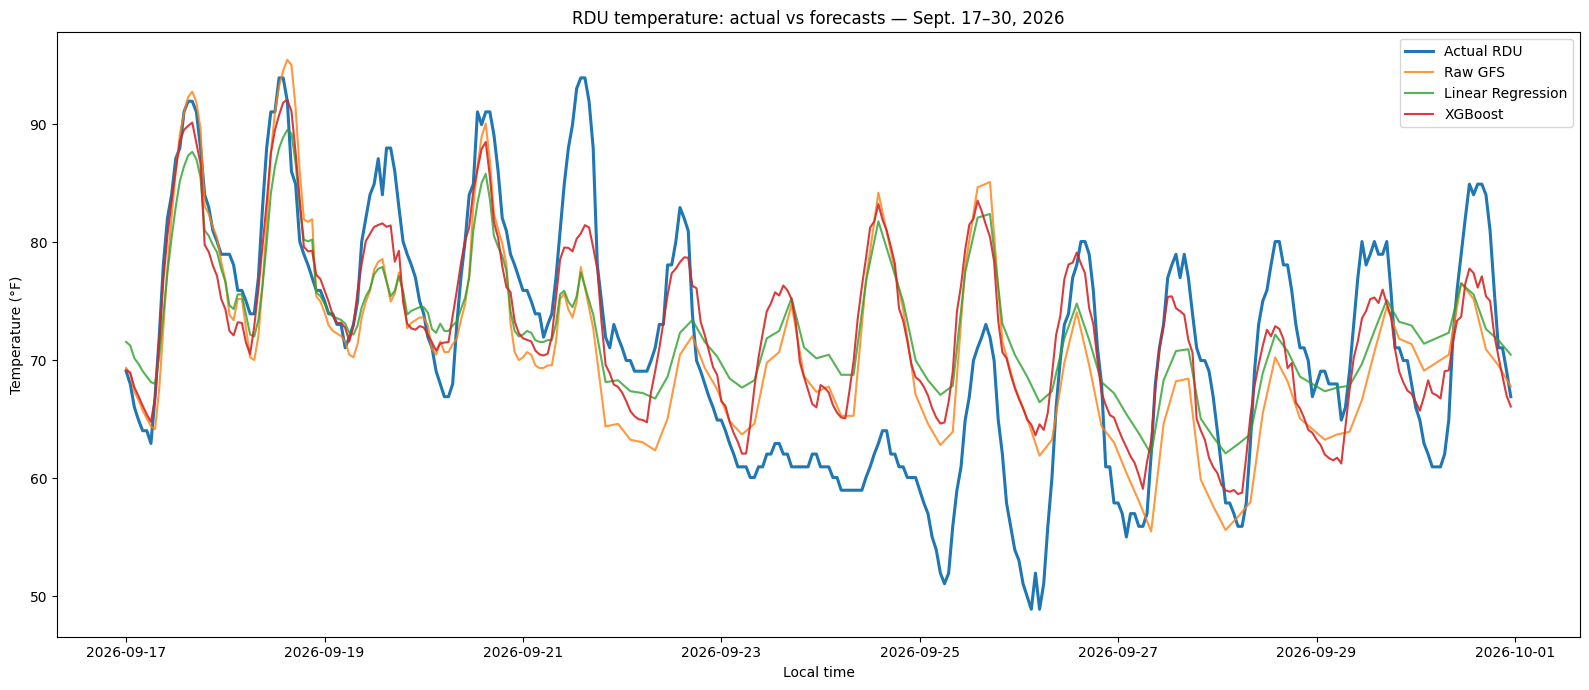

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/01_actual_vs_all_forecasts_FULL336.png


In [16]:
plt.figure(
    figsize=(16, 7)
)

plt.plot(
    evaluation[
        "valid_time_local"
    ],
    evaluation[
        "actual_temp_f"
    ],
    linewidth=2.2,
    label="Actual RDU",
)

plt.plot(
    evaluation[
        "valid_time_local"
    ],
    evaluation[
        "raw_gfs_temp_f"
    ],
    alpha=0.8,
    label="Raw GFS",
)

plt.plot(
    evaluation[
        "valid_time_local"
    ],
    evaluation[
        "linear_regression_temp_f"
    ],
    alpha=0.8,
    label="Linear Regression",
)

plt.plot(
    evaluation[
        "valid_time_local"
    ],
    evaluation[
        "xgboost_temp_f"
    ],
    alpha=0.9,
    label="XGBoost",
)

plt.title(
    "RDU temperature: actual vs forecasts — Sept. 17–30, 2026"
)

plt.xlabel(
    "Local time"
)

plt.ylabel(
    "Temperature (°F)"
)

plt.legend()
plt.tight_layout()

path = (
    FIGURE_DIR
    / "01_actual_vs_all_forecasts_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 12. Daily error vs days since Sept. 17 at 12 AM

In [17]:
daily_rows = []

for day, group in evaluation.groupby(
    "day_since_start",
    sort=True,
):
    for model_name, prediction_column in MODEL_COLUMNS.items():
        error = (
            group[
                prediction_column
            ]
            - group[
                "actual_temp_f"
            ]
        )

        daily_rows.append({
            "day_since_start": day,
            "calendar_date": str(
                group[
                    "valid_time_local"
                ].dt.date.iloc[0]
            ),
            "model": model_name,
            "n_hours": len(
                group
            ),
            "MAE_F": error.abs().mean(),
            "RMSE_F": np.sqrt(
                np.mean(
                    error ** 2
                )
            ),
            "Bias_F": error.mean(),
        })


metrics_by_day = pd.DataFrame(
    daily_rows
)

display(
    metrics_by_day.pivot(
        index=[
            "day_since_start",
            "calendar_date",
        ],
        columns="model",
        values="MAE_F",
    ).round(3)
)

,model,Linear Regression,Raw GFS,XGBoost
day_since_start,calendar_date,,,
0,2026-09-17,3.344,1.481,1.769
1,2026-09-18,3.091,3.510,2.814
2,2026-09-19,4.421,4.886,2.977
3,2026-09-20,4.561,3.484,3.286
4,2026-09-21,7.252,8.991,5.257
5,2026-09-22,4.677,6.639,3.265
6,2026-09-23,8.916,6.306,7.510
7,2026-09-24,13.000,11.777,12.402
8,2026-09-25,12.381,11.085,11.706


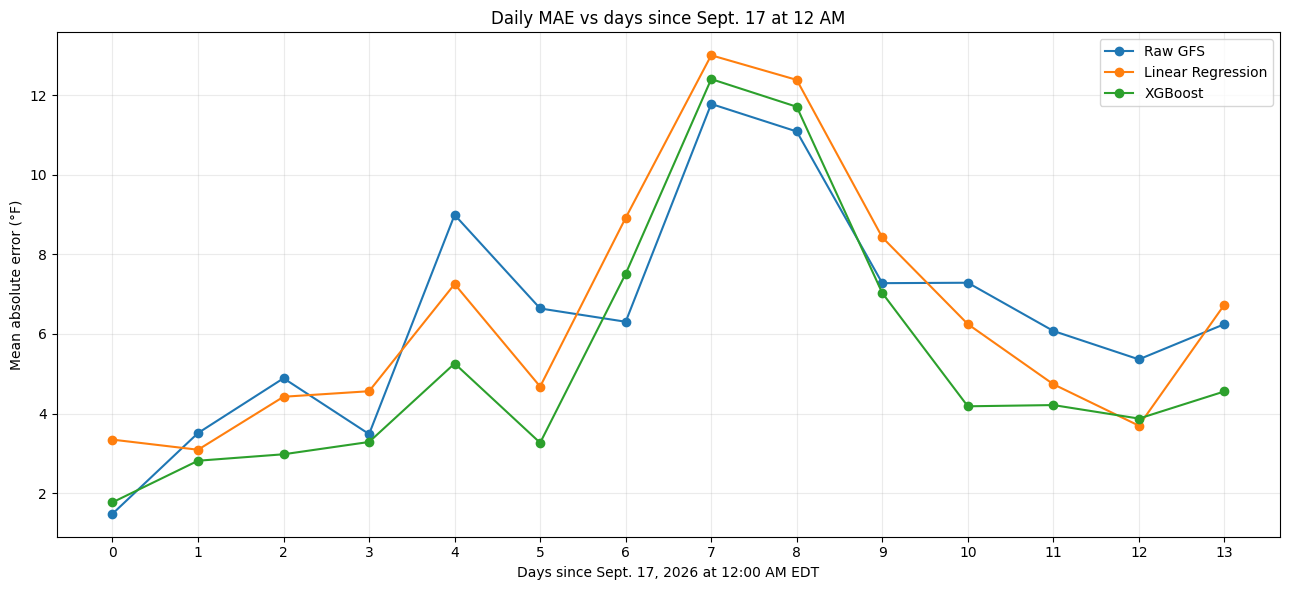

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/02_daily_mae_vs_days_since_start_FULL336.png


In [18]:
plt.figure(
    figsize=(13, 6)
)

for model_name in MODEL_COLUMNS:
    d = metrics_by_day[
        metrics_by_day[
            "model"
        ] == model_name
    ]

    plt.plot(
        d[
            "day_since_start"
        ],
        d[
            "MAE_F"
        ],
        marker="o",
        label=model_name,
    )

plt.title(
    "Daily MAE vs days since Sept. 17 at 12 AM"
)

plt.xlabel(
    "Days since Sept. 17, 2026 at 12:00 AM EDT"
)

plt.ylabel(
    "Mean absolute error (°F)"
)

plt.xticks(
    range(14)
)

plt.legend()
plt.grid(
    alpha=0.25
)
plt.tight_layout()

path = (
    FIGURE_DIR
    / "02_daily_mae_vs_days_since_start_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 13. Trailing 24-hour MAE and bias

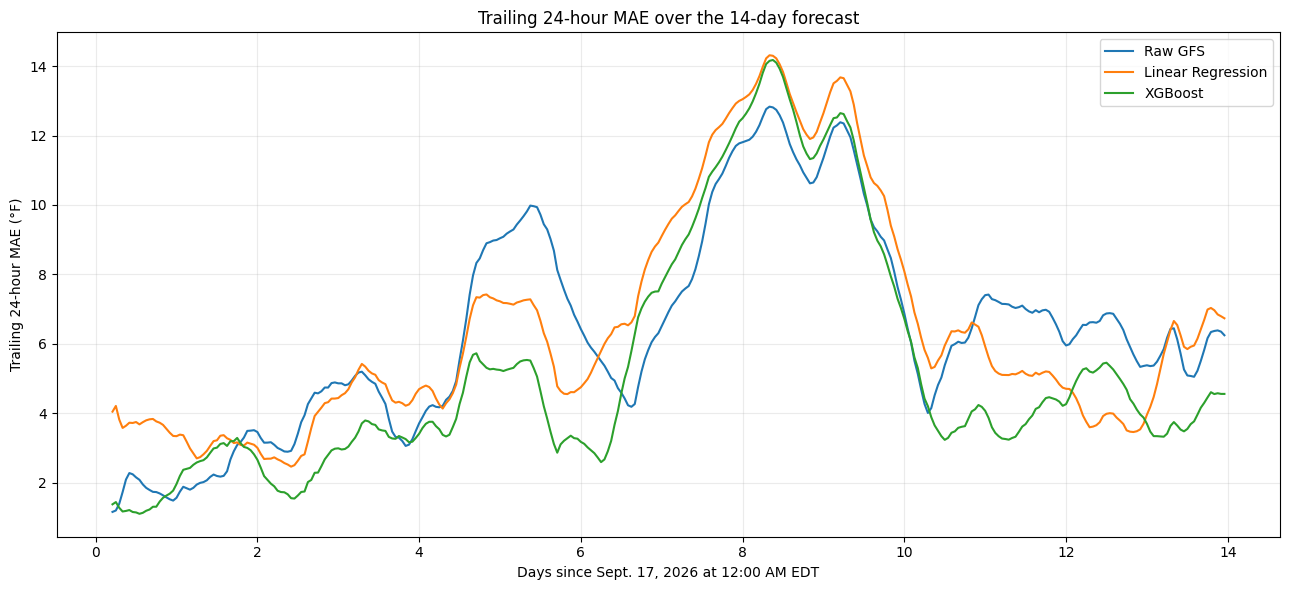

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/03_rolling_24h_mae_FULL336.png


In [19]:
rolling = (
    evaluation
    .sort_values(
        "valid_time_utc"
    )
    .copy()
)

plt.figure(
    figsize=(13, 6)
)

for model_name in MODEL_COLUMNS:
    prefix = model_prefix(
        model_name
    )

    rolling[
        f"{prefix}_rolling_24h_mae_f"
    ] = (
        rolling[
            f"{prefix}_abs_error_f"
        ]
        .rolling(
            24,
            min_periods=6,
        )
        .mean()
    )

    plt.plot(
        rolling[
            "days_since_sep17_midnight"
        ],
        rolling[
            f"{prefix}_rolling_24h_mae_f"
        ],
        label=model_name,
    )

plt.title(
    "Trailing 24-hour MAE over the 14-day forecast"
)

plt.xlabel(
    "Days since Sept. 17, 2026 at 12:00 AM EDT"
)

plt.ylabel(
    "Trailing 24-hour MAE (°F)"
)

plt.legend()
plt.grid(
    alpha=0.25
)
plt.tight_layout()

path = (
    FIGURE_DIR
    / "03_rolling_24h_mae_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

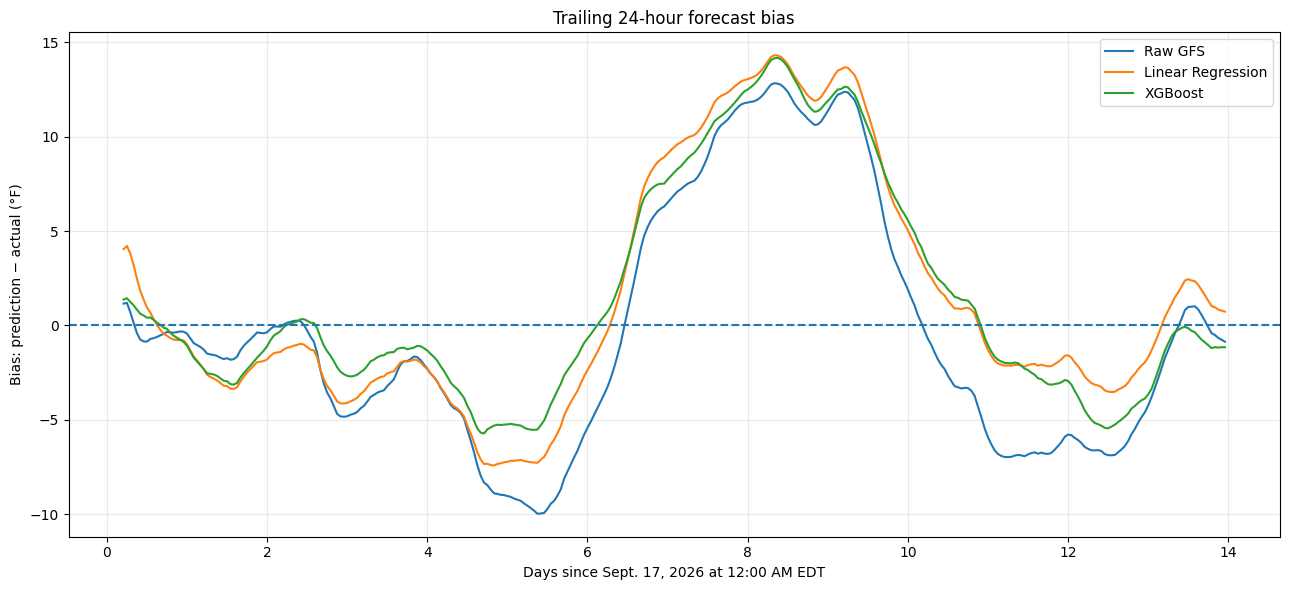

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/04_rolling_24h_bias_FULL336.png


In [20]:
plt.figure(
    figsize=(13, 6)
)

for model_name in MODEL_COLUMNS:
    prefix = model_prefix(
        model_name
    )

    rolling_bias = (
        rolling[
            f"{prefix}_error_f"
        ]
        .rolling(
            24,
            min_periods=6,
        )
        .mean()
    )

    plt.plot(
        rolling[
            "days_since_sep17_midnight"
        ],
        rolling_bias,
        label=model_name,
    )

plt.axhline(
    0,
    linestyle="--",
)

plt.title(
    "Trailing 24-hour forecast bias"
)

plt.xlabel(
    "Days since Sept. 17, 2026 at 12:00 AM EDT"
)

plt.ylabel(
    "Bias: prediction − actual (°F)"
)

plt.legend()
plt.grid(
    alpha=0.25
)
plt.tight_layout()

path = (
    FIGURE_DIR
    / "04_rolling_24h_bias_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 14. Short-, medium-, and long-range performance

In [21]:
def horizon_group(
    day,
):
    if day <= 2:
        return "Days 1–3"

    if day <= 6:
        return "Days 4–7"

    return "Days 8–14"


evaluation[
    "horizon_group"
] = (
    evaluation[
        "day_since_start"
    ]
    .map(
        horizon_group
    )
)


horizon_rows = []

for horizon_name in [
    "Days 1–3",
    "Days 4–7",
    "Days 8–14",
]:
    h = evaluation[
        evaluation[
            "horizon_group"
        ] == horizon_name
    ]

    for model_name, prediction_column in MODEL_COLUMNS.items():
        error = (
            h[
                prediction_column
            ]
            - h[
                "actual_temp_f"
            ]
        )

        horizon_rows.append({
            "horizon_group": horizon_name,
            "model": model_name,
            "n_hours": len(
                h
            ),
            "RMSE_F": np.sqrt(
                np.mean(
                    error ** 2
                )
            ),
            "MAE_F": error.abs().mean(),
            "Bias_F": error.mean(),
        })


metrics_by_horizon = pd.DataFrame(
    horizon_rows
)

display(
    metrics_by_horizon.round(3)
)

,horizon_group,model,n_hours,RMSE_F,MAE_F,Bias_F
0,Days 1–3,Raw GFS,72,4.411,3.292,-1.864
1,Days 1–3,Linear Regression,72,4.522,3.619,-2.275
2,Days 1–3,XGBoost,72,3.139,2.520,-1.600
3,Days 4–7,Raw GFS,96,7.619,6.355,-2.636
4,Days 4–7,Linear Regression,96,7.539,6.351,-0.796
5,Days 4–7,XGBoost,96,6.113,4.829,0.030
6,Days 8–14,Raw GFS,168,9.048,7.872,1.190
7,Days 8–14,Linear Regression,168,9.269,7.888,3.858
8,Days 8–14,XGBoost,168,8.372,6.851,3.061


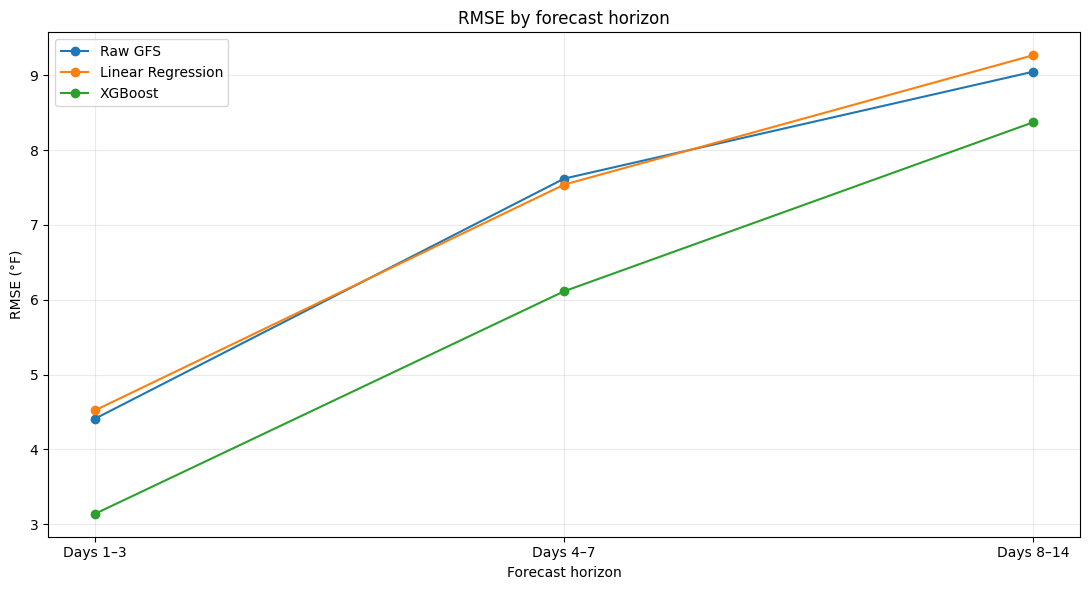

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/05_rmse_by_horizon_FULL336.png


In [22]:
order = [
    "Days 1–3",
    "Days 4–7",
    "Days 8–14",
]

positions = np.arange(
    len(order)
)

plt.figure(
    figsize=(11, 6)
)

for model_name in MODEL_COLUMNS:
    d = (
        metrics_by_horizon[
            metrics_by_horizon[
                "model"
            ] == model_name
        ]
        .set_index(
            "horizon_group"
        )
        .loc[
            order
        ]
        .reset_index()
    )

    plt.plot(
        positions,
        d[
            "RMSE_F"
        ],
        marker="o",
        label=model_name,
    )

plt.xticks(
    positions,
    order,
)

plt.title(
    "RMSE by forecast horizon"
)

plt.xlabel(
    "Forecast horizon"
)

plt.ylabel(
    "RMSE (°F)"
)

plt.legend()
plt.grid(
    alpha=0.25
)
plt.tight_layout()

path = (
    FIGURE_DIR
    / "05_rmse_by_horizon_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 15. Which forecast was closest most often?

,hours_closest,percent_of_336_hours
closest_model,,
Raw GFS,101,30.06
Linear Regression,80,23.81
XGBoost,155,46.13


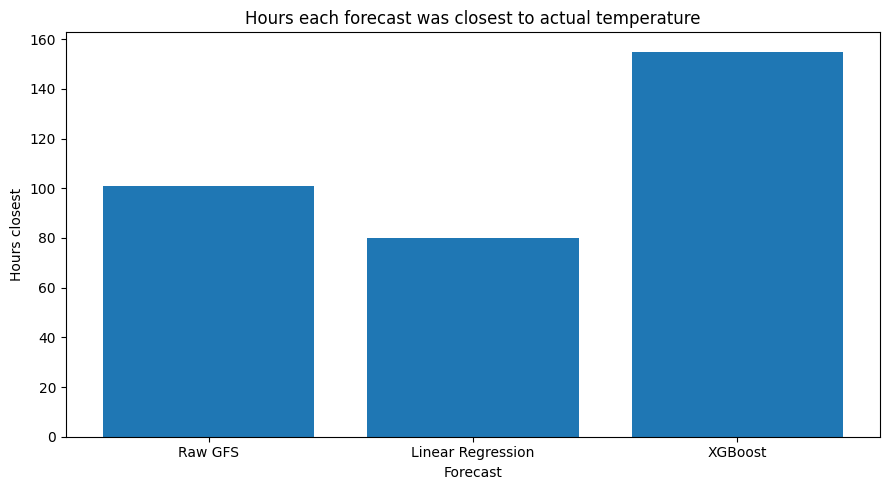

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/06_hours_each_model_was_closest_FULL336.png


In [23]:
abs_error_columns = {
    model_name: (
        f"{model_prefix(model_name)}"
        "_abs_error_f"
    )
    for model_name
    in MODEL_COLUMNS
}

reverse_lookup = {
    column: model_name
    for model_name, column
    in abs_error_columns.items()
}

evaluation[
    "closest_model"
] = (
    evaluation[
        list(
            abs_error_columns.values()
        )
    ]
    .idxmin(
        axis=1
    )
    .map(
        reverse_lookup
    )
)

win_counts = (
    evaluation[
        "closest_model"
    ]
    .value_counts()
    .reindex(
        list(
            MODEL_COLUMNS.keys()
        ),
        fill_value=0,
    )
)

closest_summary = pd.DataFrame({
    "hours_closest": win_counts,
    "percent_of_336_hours": (
        100
        * win_counts
        / 336
    ),
})

display(
    closest_summary.round(2)
)

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    closest_summary.index,
    closest_summary[
        "hours_closest"
    ],
)

plt.title(
    "Hours each forecast was closest to actual temperature"
)

plt.xlabel(
    "Forecast"
)

plt.ylabel(
    "Hours closest"
)

plt.tight_layout()

path = (
    FIGURE_DIR
    / "06_hours_each_model_was_closest_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 16. Absolute-error distribution

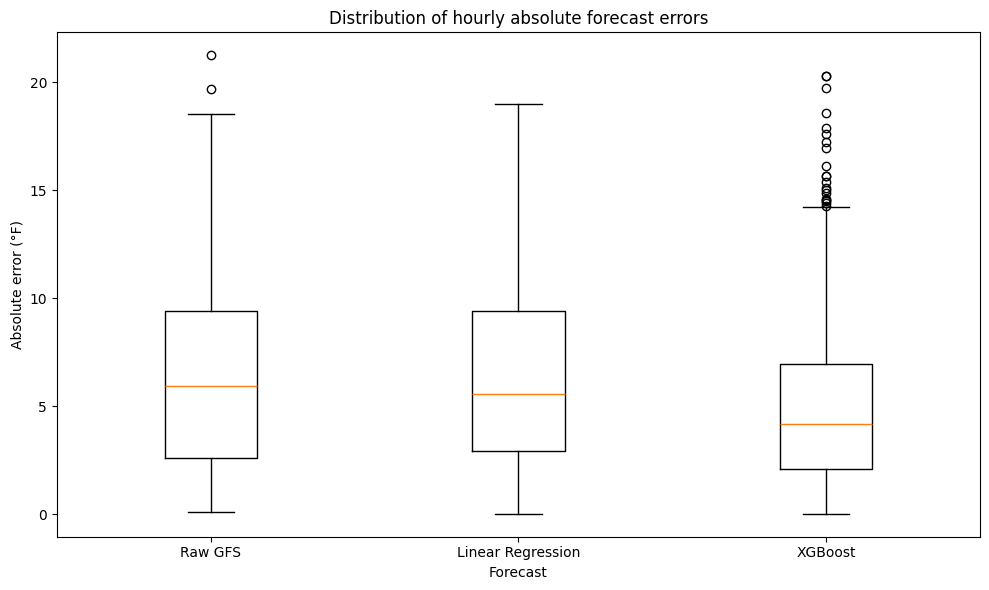

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/07_absolute_error_distribution_FULL336.png


In [24]:
box_data = [
    evaluation[
        f"{model_prefix(name)}"
        "_abs_error_f"
    ].to_numpy()
    for name
    in MODEL_COLUMNS
]

plt.figure(
    figsize=(10, 6)
)

plt.boxplot(
    box_data,
    tick_labels=list(
        MODEL_COLUMNS.keys()
    ),
    showfliers=True,
)

plt.title(
    "Distribution of hourly absolute forecast errors"
)

plt.xlabel(
    "Forecast"
)

plt.ylabel(
    "Absolute error (°F)"
)

plt.tight_layout()

path = (
    FIGURE_DIR
    / "07_absolute_error_distribution_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 17. Performance by local hour of day

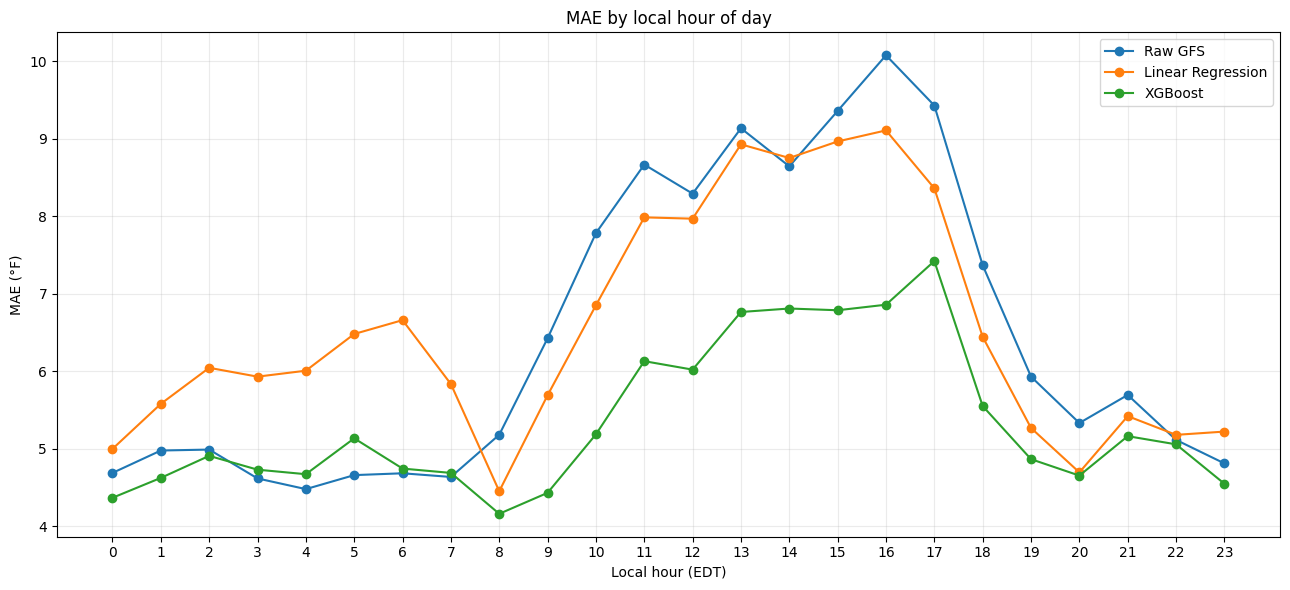

Saved: /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/reports/figures/final_2026_full336/08_mae_by_local_hour_FULL336.png


In [25]:
hour_rows = []

for local_hour, group in evaluation.groupby(
    "local_hour",
    sort=True,
):
    for model_name, prediction_column in MODEL_COLUMNS.items():
        error = (
            group[
                prediction_column
            ]
            - group[
                "actual_temp_f"
            ]
        )

        hour_rows.append({
            "local_hour": local_hour,
            "model": model_name,
            "MAE_F": error.abs().mean(),
            "Bias_F": error.mean(),
            "n_hours": len(
                group
            ),
        })


metrics_by_hour = pd.DataFrame(
    hour_rows
)

plt.figure(
    figsize=(13, 6)
)

for model_name in MODEL_COLUMNS:
    d = metrics_by_hour[
        metrics_by_hour[
            "model"
        ] == model_name
    ]

    plt.plot(
        d[
            "local_hour"
        ],
        d[
            "MAE_F"
        ],
        marker="o",
        label=model_name,
    )

plt.title(
    "MAE by local hour of day"
)

plt.xlabel(
    "Local hour (EDT)"
)

plt.ylabel(
    "MAE (°F)"
)

plt.xticks(
    range(24)
)

plt.legend()
plt.grid(
    alpha=0.25
)
plt.tight_layout()

path = (
    FIGURE_DIR
    / "08_mae_by_local_hour_FULL336.png"
)

plt.savefig(
    path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    path,
)

## 18. Largest misses

In [26]:
largest_miss_rows = []

for model_name, prediction_column in MODEL_COLUMNS.items():
    prefix = model_prefix(
        model_name
    )

    top = (
        evaluation[
            [
                "valid_time_local",
                "actual_temp_f",
                prediction_column,
                f"{prefix}_error_f",
                f"{prefix}_abs_error_f",
            ]
        ]
        .nlargest(
            10,
            f"{prefix}_abs_error_f",
        )
        .copy()
    )

    top[
        "model"
    ] = model_name

    top = top.rename(
        columns={
            prediction_column: "prediction_temp_f",
            f"{prefix}_error_f": "error_f",
            f"{prefix}_abs_error_f": "abs_error_f",
        }
    )

    largest_miss_rows.append(
        top[
            [
                "model",
                "valid_time_local",
                "actual_temp_f",
                "prediction_temp_f",
                "error_f",
                "abs_error_f",
            ]
        ]
    )


largest_misses = pd.concat(
    largest_miss_rows,
    ignore_index=True,
)

display(
    largest_misses.round(3)
)

,model,valid_time_local,actual_temp_f,prediction_temp_f,error_f,abs_error_f
0,Raw GFS,2026-09-24 14:00:00-04:00,62.96,84.200,21.240,21.240
1,Raw GFS,2026-09-24 13:00:00-04:00,62.06,81.725,19.665,19.665
2,Raw GFS,2026-09-24 15:00:00-04:00,64.04,82.550,18.510,18.510
3,Raw GFS,2026-09-24 12:00:00-04:00,60.98,79.250,18.270,18.270
4,Raw GFS,2026-09-21 13:00:00-04:00,93.02,74.975,-18.045,18.045
5,Raw GFS,2026-09-21 15:00:00-04:00,93.92,76.175,-17.745,17.745
6,Raw GFS,2026-09-21 16:00:00-04:00,91.94,74.450,-17.490,17.490
7,Raw GFS,2026-09-24 17:00:00-04:00,62.06,79.250,17.190,17.190
8,Raw GFS,2026-09-24 16:00:00-04:00,64.04,80.900,16.860,16.860
9,Raw GFS,2026-09-24 11:00:00-04:00,60.08,76.775,16.695,16.695


## 19. Save final 336-hour evaluation tables

In [27]:
HOURLY_OUTPUT = (
    PROCESSED_DIR
    / "final_2026_evaluation_hourly_FULL336.csv"
)

OVERALL_OUTPUT = (
    PROCESSED_DIR
    / "final_2026_metrics_overall_FULL336.csv"
)

BY_DAY_OUTPUT = (
    PROCESSED_DIR
    / "final_2026_metrics_by_day_FULL336.csv"
)

BY_HORIZON_OUTPUT = (
    PROCESSED_DIR
    / "final_2026_metrics_by_horizon_FULL336.csv"
)

evaluation.to_csv(
    HOURLY_OUTPUT,
    index=False,
)

overall_metrics.to_csv(
    OVERALL_OUTPUT,
    index=False,
)

metrics_by_day.to_csv(
    BY_DAY_OUTPUT,
    index=False,
)

metrics_by_horizon.to_csv(
    BY_HORIZON_OUTPUT,
    index=False,
)

print("Saved:")
print(" ", HOURLY_OUTPUT)
print(" ", OVERALL_OUTPUT)
print(" ", BY_DAY_OUTPUT)
print(" ", BY_HORIZON_OUTPUT)

Saved:
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/final_2026_evaluation_hourly_FULL336.csv
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/final_2026_metrics_overall_FULL336.csv
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/final_2026_metrics_by_day_FULL336.csv
  /home/konurnordberg/aipi/520-models/projects/weather-prediction-RDU/data/processed/final_2026_metrics_by_horizon_FULL336.csv


## 20. Final summary

In [28]:
display(
    overall_metrics[
        [
            "model",
            "n_hours",
            "RMSE_F",
            "MAE_F",
            "Bias_F",
            "R2",
            "RMSE_improvement_vs_GFS_pct",
            "MAE_improvement_vs_GFS_pct",
        ]
    ].round(4)
)

best_rmse = (
    overall_metrics
    .sort_values(
        "RMSE_F"
    )
    .iloc[0]
)

best_mae = (
    overall_metrics
    .sort_values(
        "MAE_F"
    )
    .iloc[0]
)

print(
    "\nBest model by RMSE:",
    best_rmse[
        "model"
    ],
    f"({best_rmse['RMSE_F']:.3f} °F)",
)

print(
    "Best model by MAE:",
    best_mae[
        "model"
    ],
    f"({best_mae['MAE_F']:.3f} °F)",
)

print(
    "\nGround-truth source counts:"
)

print(
    full_actual[
        "actual_source"
    ]
    .value_counts()
)

print(
    "\nThis is now the complete 336/336-hour final evaluation. "
    "No missing actual target hours remain."
)

,model,n_hours,RMSE_F,MAE_F,Bias_F,R2,RMSE_improvement_vs_GFS_pct,MAE_improvement_vs_GFS_pct
0,XGBoost,336,6.9163,5.3455,1.1964,0.5449,11.9437,17.2166
1,Raw GFS,336,7.8544,6.4572,-0.5575,0.4131,0.0000,0.0000
2,Linear Regression,336,7.9733,6.5344,1.2142,0.3952,-1.5143,-1.1960



Best model by RMSE: XGBoost (6.916 °F)
Best model by MAE: XGBoost (5.345 °F)

Ground-truth source counts:
actual_source
NOAA_GHCNh        322
NOAA_AWC_METAR     14
Name: count, dtype: int64

This is now the complete 336/336-hour final evaluation. No missing actual target hours remain.
